In [3]:
!wget -O double_torus.off https://raw.githubusercontent.com/bab2min/meshrenderer/master/test/meshgenus2.off

--2025-05-17 02:03:34--  https://raw.githubusercontent.com/bab2min/meshrenderer/master/test/meshgenus2.off
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-05-17 02:03:34 ERROR 404: Not Found.



In [4]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.1/711.1 kB 9.8 MB/s eta 0:00:00


<ipython-input-5-f5cfc9ca90ae>:33: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  scene.remove_duplicate_faces()
<ipython-input-5-f5cfc9ca90ae>:34: DeprecationWarning: `remove_degenerate_faces` is deprecated and will be removed in March 2024 replace with `self.update_faces(self.nondegenerate_faces(height=height))`
  scene.remove_degenerate_faces()


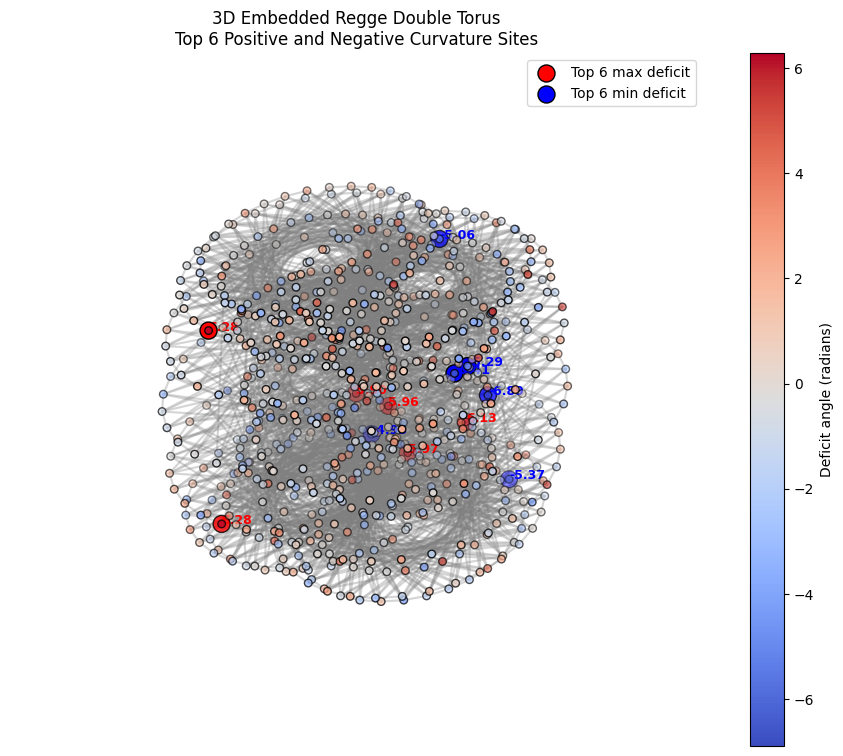

Vertices: 768, Faces: 1536
Top 6 deficit angles: [6.28318531 6.28318531 6.13175379 5.97320266 5.95900079 5.89696321]
Bottom 6 deficit angles: [-6.88962969 -6.4082958  -5.37389328 -5.28521887 -5.05706073 -4.95143287]
Sum of all deficit angles (should be ~-4pi for genus 2): -7.993605777301127e-15


In [5]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt

# Function to generate a double torus mesh (two tori fused together)
def make_double_torus(N_major=32, N_minor=12, R=2.0, r=0.7, separation=2.1):
    # Generate two tori, offset in x
    tori = []
    for dx in [-separation/2, separation/2]:
        theta = np.linspace(0, 2 * np.pi, N_major, endpoint=False)
        phi = np.linspace(0, 2 * np.pi, N_minor, endpoint=False)
        theta, phi = np.meshgrid(theta, phi)
        theta = theta.ravel()
        phi = phi.ravel()
        x = (R + r * np.cos(phi)) * np.cos(theta) + dx
        y = (R + r * np.cos(phi)) * np.sin(theta)
        z = r * np.sin(phi)
        verts = np.vstack([x, y, z]).T
        # Create face indices
        faces = []
        for i in range(N_major):
            for j in range(N_minor):
                a = i * N_minor + j
                b = ((i+1)%N_major) * N_minor + j
                c = i * N_minor + (j+1)%N_minor
                d = ((i+1)%N_major) * N_minor + (j+1)%N_minor
                faces.append([a, b, c])
                faces.append([b, d, c])
        tori.append(trimesh.Trimesh(vertices=verts, faces=faces))
    # Fuse the two tori with a Boolean union
    scene = trimesh.util.concatenate(tori)
    # Remove duplicate vertices/faces (trimesh repair)
    scene.remove_duplicate_faces()
    scene.remove_degenerate_faces()
    scene.remove_unreferenced_vertices()
    scene.process(validate=True)
    return scene

# --- Generate the mesh ---
mesh = make_double_torus()
verts = mesh.vertices
faces = mesh.faces
N_points = len(verts)

# --- Assign random entanglement to each edge ---
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)
np.random.seed(0)
entanglement = {e: 0.7 + 0.3 * np.random.rand() for e in edges}
def edge_length(E):
    return -np.log(E) if E > 0 else 1e6
edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- Compute vertex angle sums ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(N_points)
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- Find top/bottom 6 deficit vertices ---
N = 6
topN_idx = np.argsort(deficit_angles)[-N:][::-1]
botN_idx = np.argsort(deficit_angles)[:N]

# --- 3D Plot with highlights ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.18)
# Main scatter plot
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=30, edgecolors='k')
# Highlight top/bottom 6
ax.scatter(verts[topN_idx, 0], verts[topN_idx, 1], verts[topN_idx, 2],
           color='red', s=150, edgecolors='black', label='Top 6 max deficit')
ax.scatter(verts[botN_idx, 0], verts[botN_idx, 1], verts[botN_idx, 2],
           color='blue', s=150, edgecolors='black', label='Top 6 min deficit')
for idx in topN_idx:
    ax.text(verts[idx, 0], verts[idx, 1], verts[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='red', fontsize=9, weight='bold')
for idx in botN_idx:
    ax.text(verts[idx, 0], verts[idx, 1], verts[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='blue', fontsize=9, weight='bold')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Double Torus\nTop 6 Positive and Negative Curvature Sites')
ax.set_axis_off()
ax.legend()
plt.show()

print(f"Vertices: {N_points}, Faces: {len(faces)}")
print("Top 6 deficit angles:", deficit_angles[topN_idx])
print("Bottom 6 deficit angles:", deficit_angles[botN_idx])
print("Sum of all deficit angles (should be ~-4pi for genus 2):", np.sum(deficit_angles))

In [6]:
!wget -O double_torus.off https://raw.githubusercontent.com/alecjacobson/gptoolbox/master/test/meshgenus2.off

--2025-05-17 02:05:49--  https://raw.githubusercontent.com/alecjacobson/gptoolbox/master/test/meshgenus2.off
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-05-17 02:05:49 ERROR 404: Not Found.



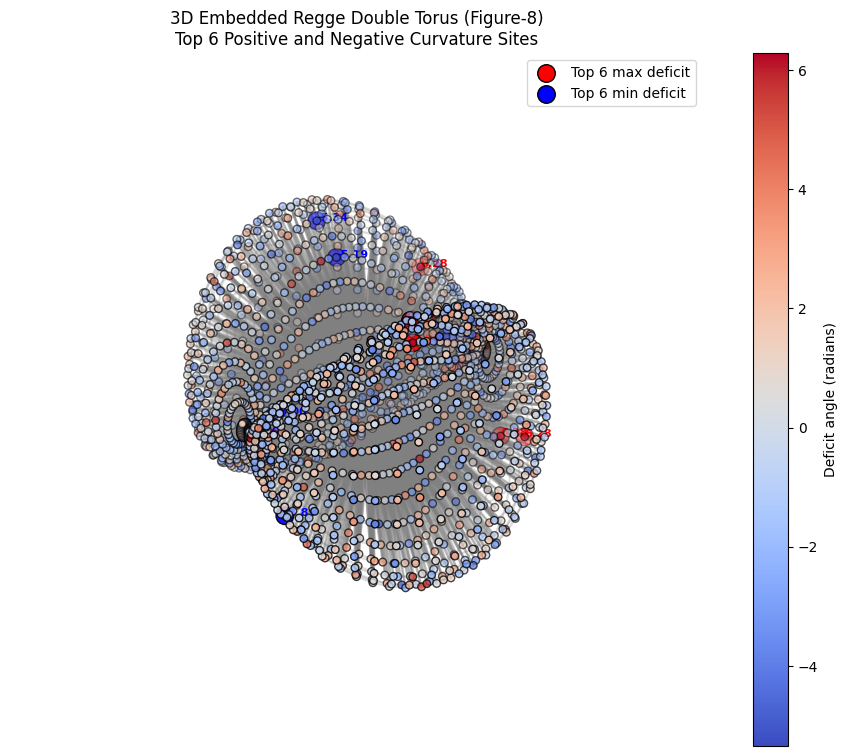

Vertices: 1800, Faces: 3600
Top 6 deficit angles: [6.28318531 6.28318531 6.28318531 6.28318531 6.28318531 6.15659443]
Bottom 6 deficit angles: [-5.34197362 -5.18809126 -5.00231725 -4.90043522 -4.88575469 -4.65721747]
Sum of all deficit angles (should be ~-4pi for genus 2): 4.618527782440651e-14


In [7]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt

# Generate a parametric genus-2 surface ("double torus")
def genus2_surface(u_steps=60, v_steps=30, a=1.0, c=2.0):
    u = np.linspace(0, 2*np.pi, u_steps, endpoint=False)
    v = np.linspace(0, 2*np.pi, v_steps, endpoint=False)
    u, v = np.meshgrid(u, v)
    u = u.ravel()
    v = v.ravel()
    # Parametric "figure-8" surface
    x = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.cos(u)
    y = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.sin(u)
    z = a * (np.cos(u) - 0.5 * np.sin(u)) * np.sin(v)
    verts = np.vstack([x, y, z]).T

    # Triangulate the grid (periodic)
    faces = []
    for i in range(u_steps):
        for j in range(v_steps):
            a0 = i * v_steps + j
            a1 = ((i+1)%u_steps) * v_steps + j
            a2 = i * v_steps + (j+1)%v_steps
            a3 = ((i+1)%u_steps) * v_steps + (j+1)%v_steps
            faces.append([a0, a1, a2])
            faces.append([a1, a3, a2])
    faces = np.array(faces)
    return verts, faces

verts, faces = genus2_surface(u_steps=60, v_steps=30)
N_points = len(verts)

# --- Assign random entanglement to each edge ---
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)
np.random.seed(0)
entanglement = {e: 0.7 + 0.3 * np.random.rand() for e in edges}
def edge_length(E):
    return -np.log(E) if E > 0 else 1e6
edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- Compute vertex angle sums ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(N_points)
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- Find top/bottom 6 deficit vertices ---
N = 6
topN_idx = np.argsort(deficit_angles)[-N:][::-1]
botN_idx = np.argsort(deficit_angles)[:N]

# --- 3D Plot with highlights ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.15)
# Main scatter plot
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=30, edgecolors='k')
# Highlight top/bottom 6
ax.scatter(verts[topN_idx, 0], verts[topN_idx, 1], verts[topN_idx, 2],
           color='red', s=160, edgecolors='black', label='Top 6 max deficit')
ax.scatter(verts[botN_idx, 0], verts[botN_idx, 1], verts[botN_idx, 2],
           color='blue', s=160, edgecolors='black', label='Top 6 min deficit')
for idx in topN_idx:
    ax.text(verts[idx, 0], verts[idx, 1], verts[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='red', fontsize=8, weight='bold')
for idx in botN_idx:
    ax.text(verts[idx, 0], verts[idx, 1], verts[idx, 2],
            f"{deficit_angles[idx]:.2f}", color='blue', fontsize=8, weight='bold')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Double Torus (Figure-8)\nTop 6 Positive and Negative Curvature Sites')
ax.set_axis_off()
ax.legend()
plt.show()

print(f"Vertices: {N_points}, Faces: {len(faces)}")
print("Top 6 deficit angles:", deficit_angles[topN_idx])
print("Bottom 6 deficit angles:", deficit_angles[botN_idx])
print("Sum of all deficit angles (should be ~-4pi for genus 2):", np.sum(deficit_angles))

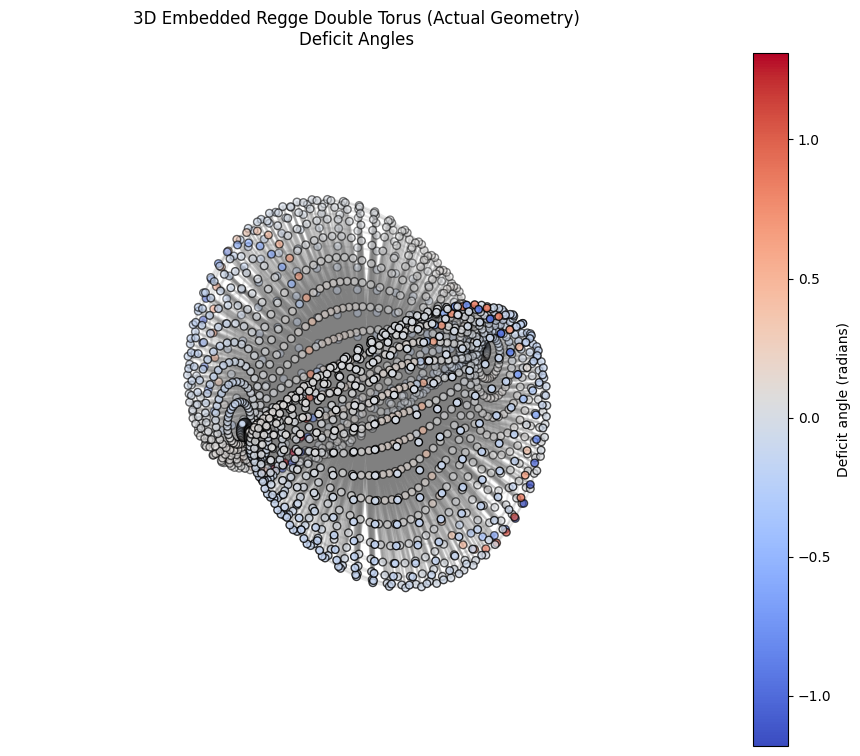

Vertices: 1800, Faces: 3600
Min deficit angle: -1.1807526684778473
Max deficit angle: 1.3107805435778932
Sum of all deficit angles (should be ~-4pi for genus 2): 1.0658141036401503e-14


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a parametric genus-2 surface ("double torus")
def genus2_surface(u_steps=60, v_steps=30, a=1.0, c=2.0):
    u = np.linspace(0, 2*np.pi, u_steps, endpoint=False)
    v = np.linspace(0, 2*np.pi, v_steps, endpoint=False)
    u, v = np.meshgrid(u, v)
    u = u.ravel()
    v = v.ravel()
    # Parametric "figure-8" surface
    x = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.cos(u)
    y = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.sin(u)
    z = a * (np.cos(u) - 0.5 * np.sin(u)) * np.sin(v)
    verts = np.vstack([x, y, z]).T

    # Triangulate the grid (periodic)
    faces = []
    for i in range(u_steps):
        for j in range(v_steps):
            a0 = i * v_steps + j
            a1 = ((i+1)%u_steps) * v_steps + j
            a2 = i * v_steps + (j+1)%v_steps
            a3 = ((i+1)%u_steps) * v_steps + (j+1)%v_steps
            faces.append([a0, a1, a2])
            faces.append([a1, a3, a2])
    faces = np.array(faces)
    return verts, faces

verts, faces = genus2_surface(u_steps=60, v_steps=30)
N_points = len(verts)

# --- Assign Regge edge lengths from 3D geometry ---
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

def edge_length_from_coords(a, b):
    return np.linalg.norm(verts[a] - verts[b])
edge_lengths = {e: edge_length_from_coords(*e) for e in edges}

# --- Compute vertex angle sums ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(N_points)
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 3D Plot of deficits ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.10)
# Main scatter plot (deficits)
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=30, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Double Torus (Actual Geometry)\nDeficit Angles')
ax.set_axis_off()
plt.show()

print(f"Vertices: {N_points}, Faces: {len(faces)}")
print("Min deficit angle:", np.min(deficit_angles))
print("Max deficit angle:", np.max(deficit_angles))
print("Sum of all deficit angles (should be ~-4pi for genus 2):", np.sum(deficit_angles))

In [10]:
!wget -O genus2.off https://www.cs.jhu.edu/~misha/Code/SurfaceReconstruction/data/genus2.off

--2025-05-17 02:14:07--  https://www.cs.jhu.edu/~misha/Code/SurfaceReconstruction/data/genus2.off
Resolving www.cs.jhu.edu (www.cs.jhu.edu)... 128.220.13.64
Connecting to www.cs.jhu.edu (www.cs.jhu.edu)|128.220.13.64|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-05-17 02:14:07 ERROR 404: Not Found.



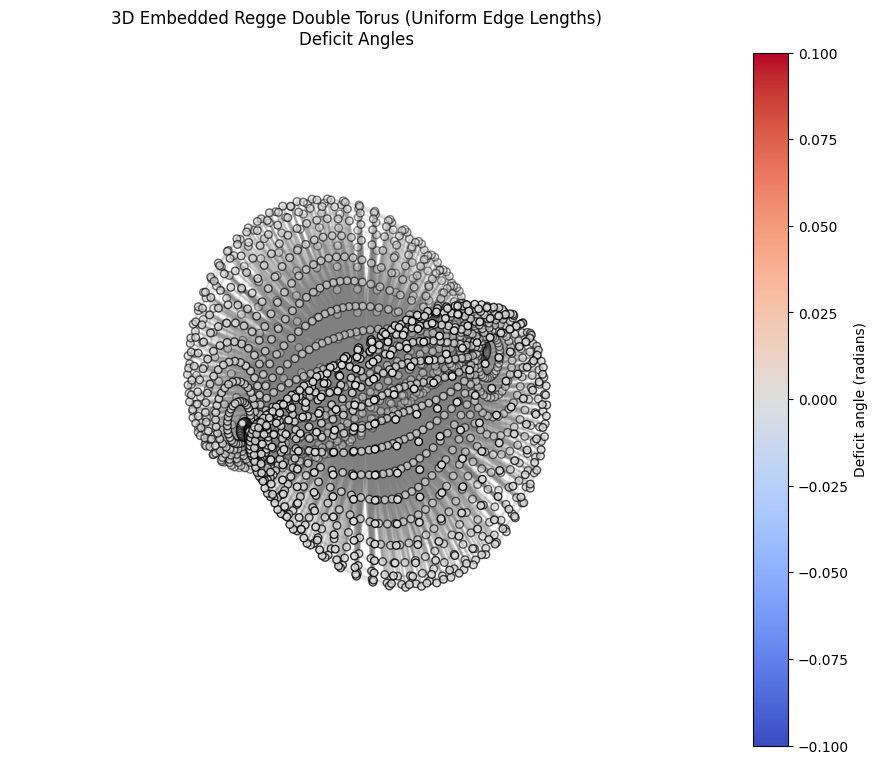

Vertices: 1800, Faces: 3600
Min deficit angle: 0.0
Max deficit angle: 0.0
Sum of all deficit angles (should be ~-4pi for genus 2): 0.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a parametric genus-2 surface ("double torus")
def genus2_surface(u_steps=60, v_steps=30, a=1.0, c=2.0):
    u = np.linspace(0, 2*np.pi, u_steps, endpoint=False)
    v = np.linspace(0, 2*np.pi, v_steps, endpoint=False)
    u, v = np.meshgrid(u, v)
    u = u.ravel()
    v = v.ravel()
    # Parametric "figure-8" surface
    x = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.cos(u)
    y = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.sin(u)
    z = a * (np.cos(u) - 0.5 * np.sin(u)) * np.sin(v)
    verts = np.vstack([x, y, z]).T

    # Triangulate the grid (periodic)
    faces = []
    for i in range(u_steps):
        for j in range(v_steps):
            a0 = i * v_steps + j
            a1 = ((i+1)%u_steps) * v_steps + j
            a2 = i * v_steps + (j+1)%v_steps
            a3 = ((i+1)%u_steps) * v_steps + (j+1)%v_steps
            faces.append([a0, a1, a2])
            faces.append([a1, a3, a2])
    faces = np.array(faces)
    return verts, faces

verts, faces = genus2_surface(u_steps=60, v_steps=30)
N_points = len(verts)

# --- Assign uniform entanglement to each edge ---
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Uniform edge lengths everywhere
entanglement = {e: np.exp(-1) for e in edges}  # All edge lengths = 1

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6
edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- Compute vertex angle sums ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(N_points)
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 3D Plot of deficits ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.10)
# Main scatter plot (deficits)
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=30, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Double Torus (Uniform Edge Lengths)\nDeficit Angles')
ax.set_axis_off()
plt.show()

print(f"Vertices: {N_points}, Faces: {len(faces)}")
print("Min deficit angle:", np.min(deficit_angles))
print("Max deficit angle:", np.max(deficit_angles))
print("Sum of all deficit angles (should be ~-4pi for genus 2):", np.sum(deficit_angles))